### NLP SENTIMENT ANALYSIS

### Goal of the project-Extracting sentiment from customer reviews on a product

In [1]:
import nltk
nltk.download('all')


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\Abhishek\AppData\Roaming

True

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import re
from nltk.corpus import stopwords

In [3]:
from nltk.stem.porter import PorterStemmer

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_excel("dataset -P657 (1).xlsx")

In [6]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [7]:
df.shape

(1440, 3)

In [8]:
df.size

4320

In [9]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [11]:
df.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [12]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [13]:
df.dropna(inplace=True)

### EDA 

In [14]:
df["rating"].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

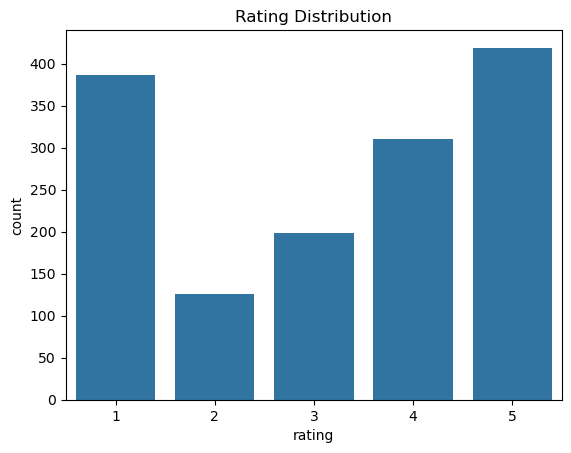

In [15]:
sns.countplot(x=df["rating"])
plt.title("Rating Distribution")
plt.show()

#### Ratings 4–5 → Positive
### Ratings 3 → Neutral
### Ratings 1–2 → Negative

In [16]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["rating"].apply(sentiment_label)

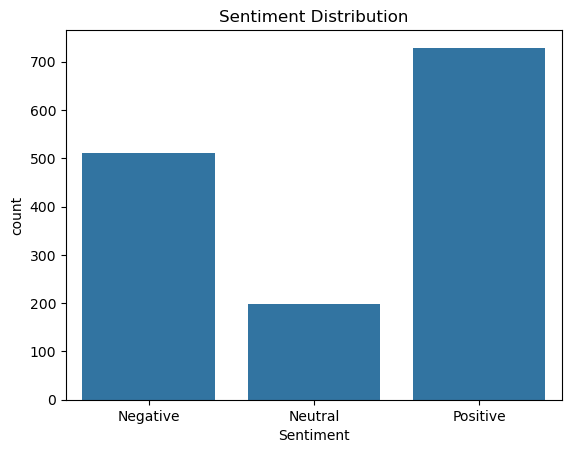

In [17]:
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

### Combine Title and Review

In [18]:
df["review"] = df["title"] + " " + df["body"]

### Review Length Analysis

In [19]:
df["review_length"] = df["review"].apply(len)

In [20]:
df["review_length"].describe()

count    1440.000000
mean      333.381944
std       229.116704
min         9.000000
25%       198.000000
50%       277.000000
75%       395.000000
max      2536.000000
Name: review_length, dtype: float64

### 3.Final Dataset for NLP

In [21]:
print(df.columns)
df.head()

Index(['title', 'rating', 'body', 'Sentiment', 'review', 'review_length'], dtype='object')


,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,Horrible product Very disappointed with the ov...,76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,Camera quality is not like 48 megapixel Camera...,61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"Overall Got the mobile on the launch date,Batt...",411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,A big no from me 1. It doesn't work with 5.0GH...,394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,Put your money somewhere else Not worth buying...,209


In [22]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Abhishek\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 1. Convert Text to Lowercase

In [23]:
print(df.columns)

Index(['title', 'rating', 'body', 'Sentiment', 'review', 'review_length'], dtype='object')


In [24]:
df["review"] = df["review"].str.lower()

In [25]:
df.head()

,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,horrible product very disappointed with the ov...,76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,camera quality is not like 48 megapixel camera...,61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"overall got the mobile on the launch date,batt...",411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,a big no from me 1. it doesn't work with 5.0gh...,394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,put your money somewhere else not worth buying...,209


### 2. Remove Special Characters

In [26]:
df["review"] = df["review"].apply(lambda x: re.sub('[^a-zA-Z ]','', x))

In [27]:
df.head()

,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,horrible product very disappointed with the ov...,76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,camera quality is not like megapixel camera q...,61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,overall got the mobile on the launch datebatte...,411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,a big no from me it doesnt work with ghz wifi...,394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,put your money somewhere else not worth buying...,209


### 3. Tokenization

In [28]:
df["review"] = df["review"].apply(lambda x: x.split())

In [29]:
df.head()

,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,"[horrible, product, very, disappointed, with, ...",76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,"[camera, quality, is, not, like, megapixel, ca...",61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"[overall, got, the, mobile, on, the, launch, d...",411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,"[a, big, no, from, me, it, doesnt, work, with,...",394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,"[put, your, money, somewhere, else, not, worth...",209


### 4. Remove Stopwords

In [30]:
stop_words = set(stopwords.words('english'))

df["review"] = df["review"].apply(
    lambda x: [word for word in x if word not in stop_words]
)

In [31]:
df.head()

,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,"[horrible, product, disappointed, overall, per...",76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,"[camera, quality, like, megapixel, camera, qua...",61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"[overall, got, mobile, launch, datebattery, mu...",411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,"[big, doesnt, work, ghz, wifi, frequency, ghz,...",394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,"[put, money, somewhere, else, worth, buyingfau...",209


### 5. Stemming

In [32]:
ps = PorterStemmer()

df["review"] = df["review"].apply(
    lambda x: [ps.stem(word) for word in x]
)

In [33]:
df.head()

,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,"[horribl, product, disappoint, overal, perform...",76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,"[camera, qualiti, like, megapixel, camera, qua...",61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"[overal, got, mobil, launch, datebatteri, must...",411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,"[big, doesnt, work, ghz, wifi, frequenc, ghz, ...",394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,"[put, money, somewher, els, worth, buyingfault...",209


### 6. Lemmatization

In [34]:
lemmatizer = WordNetLemmatizer()

df["review"] = df["review"].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

In [35]:
df.head()

,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,"[horribl, product, disappoint, overal, perform...",76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,"[camera, qualiti, like, megapixel, camera, qua...",61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"[overal, got, mobil, launch, datebatteri, must...",411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,"[big, doesnt, work, ghz, wifi, frequenc, ghz, ...",394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,"[put, money, somewher, el, worth, buyingfaulti...",209


### 7. Convert Tokens Back to Sentence

In [36]:
df["review"] = df["review"].apply(lambda x: " ".join(x))

In [37]:
df.head()

,title,rating,body,Sentiment,review,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,horribl product disappoint overal perform samsung,76
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,camera qualiti like megapixel camera qualiti low,61
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,overal got mobil launch datebatteri must appre...,411
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,big doesnt work ghz wifi frequenc ghz old scho...,394
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,put money somewher el worth buyingfaulti softw...,209


In [38]:
!pip install wordcloud

In [39]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub("[^a-zA-Z]", " ", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_review"] = df["body"].apply(clean_text)

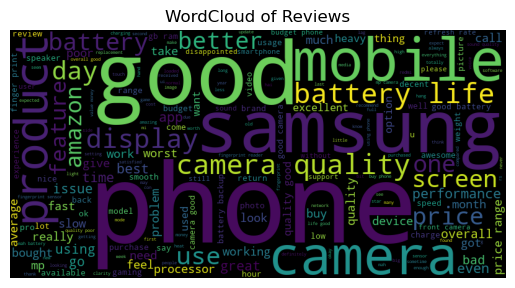

In [40]:
from wordcloud import WordCloud
text = " ".join(df["clean_review"])

wordcloud = WordCloud(width=800,height=400,background_color="black").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud of Reviews")
plt.show()

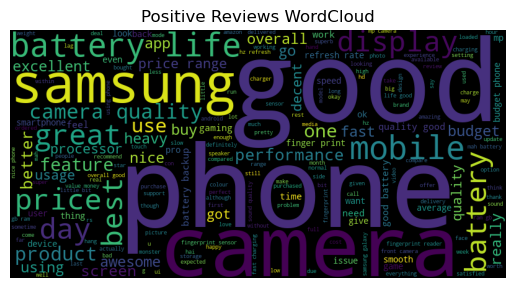

In [41]:
positive_text = " ".join(df[df["Sentiment"]=="Positive"]["clean_review"])

wordcloud = WordCloud(width=800,height=400,background_color="black").generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

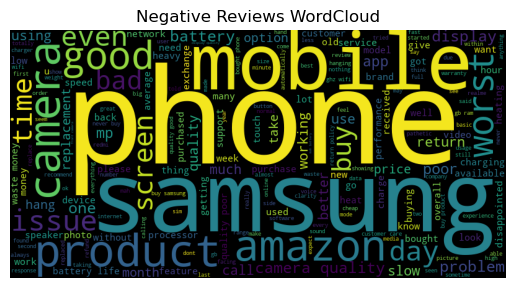

In [42]:
negative_text = " ".join(df[df["Sentiment"]=="Negative"]["clean_review"])

wordcloud = WordCloud(width=800,height=400,background_color="black").generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

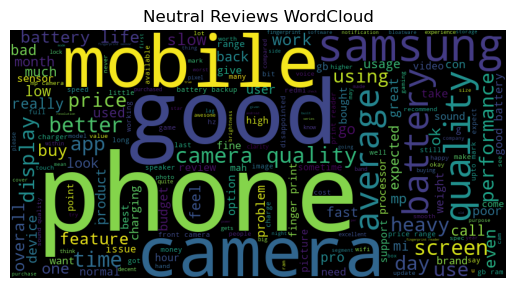

In [43]:
neutral_text = " ".join(df[df["Sentiment"]=="Neutral"]["clean_review"])

wordcloud = WordCloud(width=800, height=400, background_color="black").generate(neutral_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Neutral Reviews WordCloud")
plt.show()

### Feature Engineering

### Text Vectorization

### Text vectorization is a process in Natural Language Processing (NLP) where text (words/sentences) is converted into numbers (vectors) so that machine learning models can understand and process it.

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [45]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['Sentiment']

### Train-Test Split

### Train-test split is a method in machine learning where you divide your dataset into two parts:

Training set → used to train the model

Testing set → used to evaluate the model performance

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Building

### 1.Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [49]:
y_pred_lr = lr.predict(X_test)

In [51]:
print(y_pred_lr[:200]) 

['Positive' 'Negative' 'Positive' 'Negative' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Negative' 'Positive' 'Negative' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Negative' 'Positive' 'Negative'
 'Negative' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive' 'Negative' 'Positive'
 'Negative' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Posit

### 2.Multinomial Naive Bayes

In [52]:
from sklearn.naive_bayes import MultinomialNB

In [53]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [54]:
y_pred_nb = nb.predict(X_test)

In [55]:
print(y_pred_nb[:200]) 

['Positive' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Negative' 'Positive' 'Negative' 'Positive' 'Negative'
 'Positive' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Posit

### 3.Support Vector Machine

In [56]:
from sklearn.svm import LinearSVC

In [57]:
svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

In [58]:
y_pred_svm = svm.predict(X_test)

In [59]:
print(y_pred_svm[:200]) 

['Positive' 'Negative' 'Positive' 'Negative' 'Negative' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Negative' 'Positive' 'Negative' 'Negative' 'Negative'
 'Positive' 'Neutral' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Negative' 'Neutral' 'Negative'
 'Negative' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive' 'Negative' 'Positive'
 'Negative' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Neutral' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Positive

### 4. Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier


In [61]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [62]:
y_pred_rf = rf.predict(X_test)

In [63]:
print(y_pred_rf[:200]) 

['Positive' 'Negative' 'Positive' 'Positive' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Negative' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Negative' 'Positive' 'Negative'
 'Negative' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive' 'Negative' 'Positive'
 'Negative' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Negat

### 5.Gradient Boosting

In [64]:
from sklearn.ensemble import GradientBoostingClassifier


In [65]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [66]:
y_pred_gb = gb.predict(X_test)

In [67]:
print(y_pred_gb[:200]) 

['Negative' 'Negative' 'Positive' 'Positive' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Negative' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Neutral' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Negative' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Negative' 'Positive' 'Negative'
 'Negative' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive' 'Negative' 'Positive'
 'Negative' 'Positive' 'Negative' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Negati

### 6.XGBoost

In [68]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [69]:
from xgboost import XGBClassifier

### Convert labels to numbers

In [73]:
from sklearn.preprocessing import LabelEncoder

In [74]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [75]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [76]:
y_pred_xgb = xgb.predict(X_test)

In [77]:
print(y_pred_xgb[:200]) 

[2 0 2 2 0 2 0 0 1 2 2 2 2 0 2 0 0 0 2 1 2 2 2 0 0 2 0 2 0 0 2 0 2 0 2 2 2
 2 2 0 2 2 2 2 2 0 0 2 0 0 2 0 2 0 1 0 2 2 0 0 2 2 2 2 2 2 2 0 0 2 0 2 0 2
 2 0 2 2 2 2 2 2 0 0 2 2 2 0 0 0 2 0 0 2 2 1 0 2 2 2 0 0 0 2 2 2 0 2 2 2 2
 0 2 2 0 2 2 0 2 0 2 0 0 0 0 0 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 0 1 0 0 2 1
 2 2 0 2 0 2 2 2 0 2 0 2 2 2 2 0 0 0 0 2 1 2 2 0 2 0 2 2 2 2 2 0 2 0 2 2 2
 0 0 2 2 0 0 2 0 2 2 2 0 1 0 0]


### Convert back to labels

In [78]:
y_pred_labels = le.inverse_transform(y_pred_xgb)

In [80]:
print(y_pred_labels[:200]) 

['Positive' 'Negative' 'Positive' 'Positive' 'Negative' 'Positive'
 'Negative' 'Negative' 'Neutral' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Negative' 'Negative' 'Negative'
 'Positive' 'Neutral' 'Positive' 'Positive' 'Positive' 'Negative'
 'Negative' 'Positive' 'Negative' 'Positive' 'Negative' 'Negative'
 'Positive' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Positive'
 'Negative' 'Negative' 'Positive' 'Negative' 'Positive' 'Negative'
 'Neutral' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive' 'Negative' 'Positive'
 'Negative' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive' 'Positive' 'Negative' 'Negative' 'Negative

### model Evaluation

### Accuracy Score

### Accuracy Score is a metric used to measure how well your machine learning model is performing.

In [86]:
from sklearn.metrics import accuracy_score
results = pd.DataFrame({
    "Model": ["Logistic", "Multinomial Naive Bayes", "Support Vector Machine", "Random Forest", "Gradient Boosting","XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_svm),
         accuracy_score(y_test, y_pred_xgb)
    ]
})
print(results.sort_values(by="Accuracy", ascending=False))

                     Model  Accuracy
4        Gradient Boosting  0.802083
0                 Logistic  0.777778
2   Support Vector Machine  0.767361
3            Random Forest  0.739583
1  Multinomial Naive Bayes  0.670139
5                  XGBoost  0.000000


### F1-score

### F1-score is a model evaluation metric used mainly for classification problems, especially when classes are imbalanced like fraud detection or churn prediction.¶

In [85]:
from sklearn.metrics import f1_score

In [98]:
f1 = f1_score(y_test, y_pred_lr, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.7197857347140574


In [90]:
f1 = f1_score(y_test, y_pred_nb, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.6101937441643324


In [91]:
f1 = f1_score(y_test, y_pred_rf, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.7039954678383844


In [92]:
f1 = f1_score(y_test, y_pred_gb, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.6957516339869281


In [93]:
f1 = f1_score(y_test, y_pred_svm, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.7783568145067727


In [95]:
f1 = f1_score(y_test_enc, y_pred_xgb, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.7145213013625924


### ROC-curve of all models

In [106]:
from sklearn.svm import SVC

svm = SVC(probability=True)   # IMPORTANT
svm.fit(X_train, y_train)

y_prob_svm = svm.predict_proba(X_test)

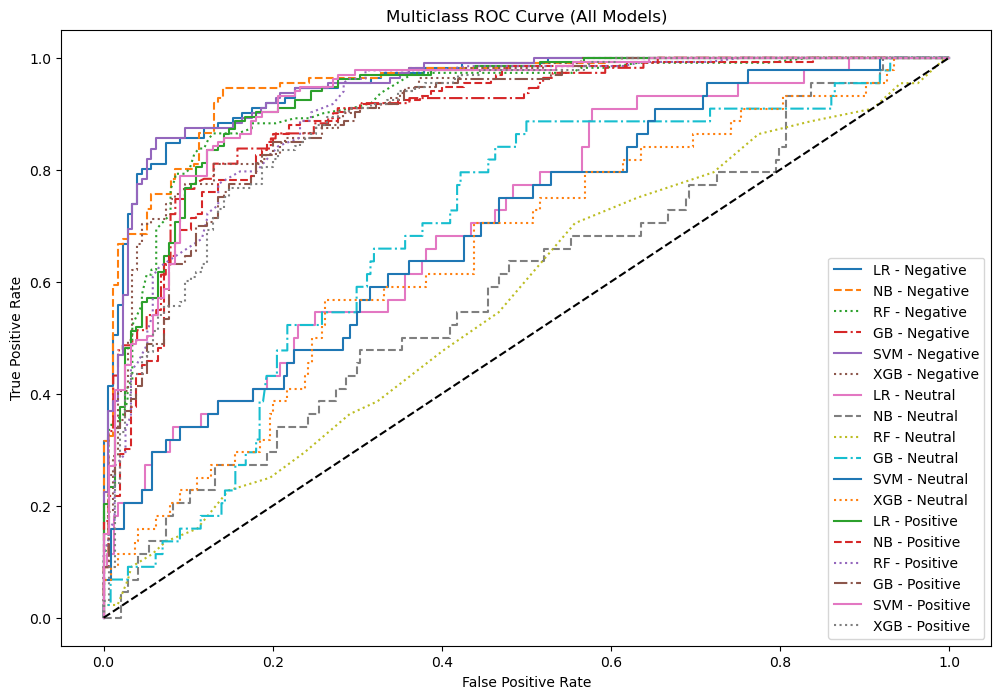

In [110]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ===== Convert labels to binary =====
classes = ['Negative', 'Neutral', 'Positive']
y_test_bin = label_binarize(y_test, classes=classes)

# ===== Probabilities (USE VECTOR DATA) =====
y_prob_lr  = lr.predict_proba(X_test)
y_prob_nb  = nb.predict_proba(X_test)
y_prob_rf  = rf.predict_proba(X_test)
y_prob_gb  = gb.predict_proba(X_test)
y_prob_svm = svm.predict_proba(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

# ===== Plot ROC =====
plt.figure(figsize=(12,8))

for i in range(len(classes)):

    # Logistic Regression
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    plt.plot(fpr, tpr, label=f"LR - {classes[i]}")

    # Naive Bayes
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_nb[:, i])
    plt.plot(fpr, tpr, linestyle='--', label=f"NB - {classes[i]}")

    # Random Forest
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    plt.plot(fpr, tpr, linestyle=':', label=f"RF - {classes[i]}")

    # Gradient Boosting
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_gb[:, i])
    plt.plot(fpr, tpr, linestyle='-.', label=f"GB - {classes[i]}")

    # SVM
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    plt.plot(fpr, tpr, linestyle='-', label=f"SVM - {classes[i]}")

    # XGBoost
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    plt.plot(fpr, tpr, linestyle=':', label=f"XGB - {classes[i]}")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (All Models)")
plt.legend()
plt.show()

### Although LinearSVC achieved competitive accuracy, Logistic Regression was selected as the final model because it provides probability outputs, is easier to interpret, and offers similar performance with better suitability for deployment.

### Model Building

In [111]:
import pickle

# Save model
pickle.dump(lr, open("model.pkl", "wb"))

# Save vectorizer
pickle.dump(tfidf, open("tfidf.pkl", "wb"))